In [1]:
# ==============================
# 1️⃣ IMPORTS
# ==============================
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import EfficientNetB0

In [2]:
BASE_DIR = r"C:\CODING\AI\PROJECTS\HC\Models\FinalDataset\fd\fd\Rotation\Gaussian"  
WORK_DIR = r"C:\CODING\AI\PROJECTS\HC\Models\Efficientnetdl"  

IMG_SIZE = (224, 224)  
BATCH_SIZE = 16
MAX_IMAGES_PER_CLASS = 200
EPOCHS = 10


In [3]:
# ==============================
# 3️⃣ FUNCTION: SAMPLE DATASET (NO DELETION)
# ==============================
def sample_dataset(src_dir, dest_dir, max_per_class):
    os.makedirs(dest_dir, exist_ok=True)
    for split in ['train', 'val', 'test']:
        for cls in os.listdir(os.path.join(src_dir, split)):
            src_cls_dir = os.path.join(src_dir, split, cls)
            dest_cls_dir = os.path.join(dest_dir, split, cls)
            os.makedirs(dest_cls_dir, exist_ok=True)

            images = os.listdir(src_cls_dir)
            random.shuffle(images)
            sampled_imgs = images[:max_per_class]
            for img in sampled_imgs:
                if not os.path.exists(os.path.join(dest_cls_dir, img)):
                    shutil.copy(os.path.join(src_cls_dir, img),
                                os.path.join(dest_cls_dir, img))

# Sample dataset
sample_dataset(BASE_DIR, WORK_DIR, MAX_IMAGES_PER_CLASS)

In [4]:

# ==============================
# 4️⃣ DATA GENERATORS (GRAYSCALE)
# ==============================
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale'  # 👈 Only 1 channel
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale'
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)


Found 3918 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.


In [5]:
# ==============================
# 5️⃣ EFFICIENTNET MODEL (GRAYSCALE, FROM SCRATCH)
# ==============================
input_tensor = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1))  # 1 channel
base_model = EfficientNetB0(weights=None, include_top=False, input_tensor=input_tensor)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

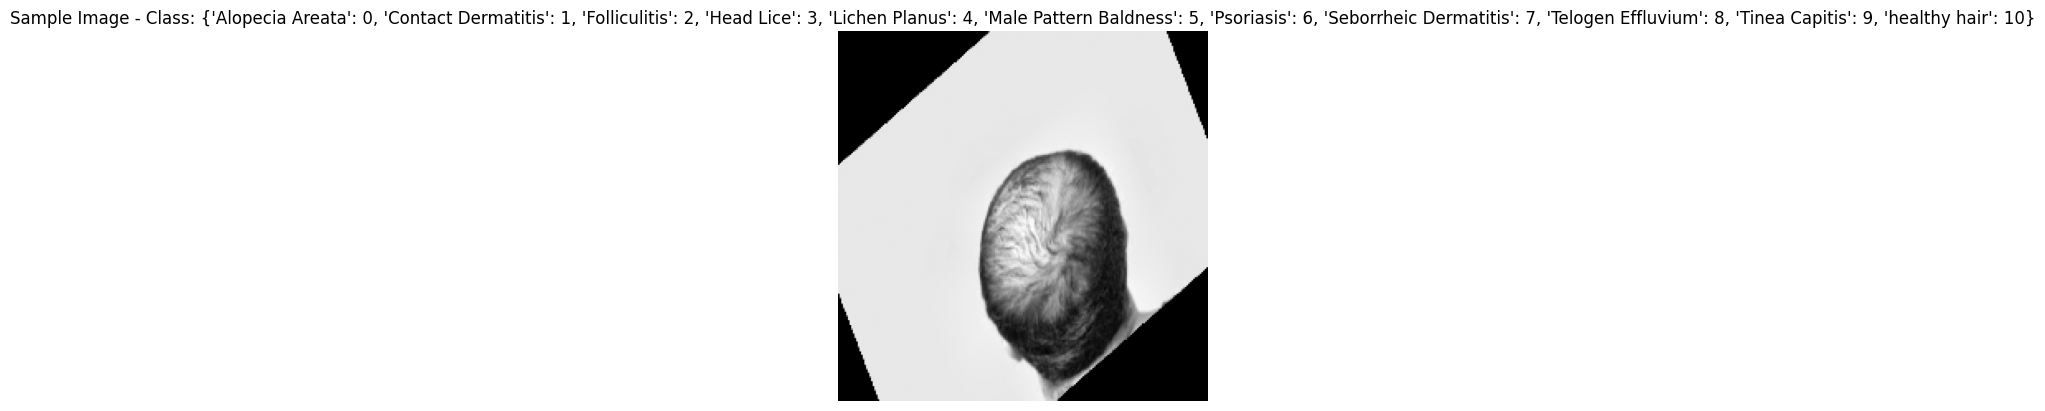

In [6]:
# ==============================
# 6️⃣ SHOW SAMPLE IMAGE
# ==============================
sample_img, sample_label = next(train_gen)
plt.imshow(sample_img[0].squeeze(), cmap='gray')
plt.title(f"Sample Image - Class: {train_gen.class_indices}")
plt.axis('off')
plt.show()

In [7]:
# ==============================
# 7️⃣ TRAINING
# ==============================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

c:\CODING\AI\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - accuracy: 0.2330 - loss: 2.2499 - val_accuracy: 0.0909 - val_loss: 3.0399
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.3453 - loss: 1.8564 - val_accuracy: 0.0909 - val_loss: 4.7213
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.4441 - loss: 1.5993 - val_accuracy: 0.2280 - val_loss: 2.6075
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - accuracy: 0.5278 - loss: 1.3675 - val_accuracy: 0.3303 - val_loss: 2.6715
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - accuracy: 0.5957 - loss: 1.1895 - val_accuracy: 0.1265 - val_loss: 3.7808
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - accuracy: 0.6531 - loss: 1.0096 - val_accuracy: 0.4689 - val_loss: 1.7500
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - accuracy: 0.7203 - loss: 0.8023 - val_accuracy: 0.6106 - val_loss: 1.3757
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.7795 - loss: 0.6520 - val_accu

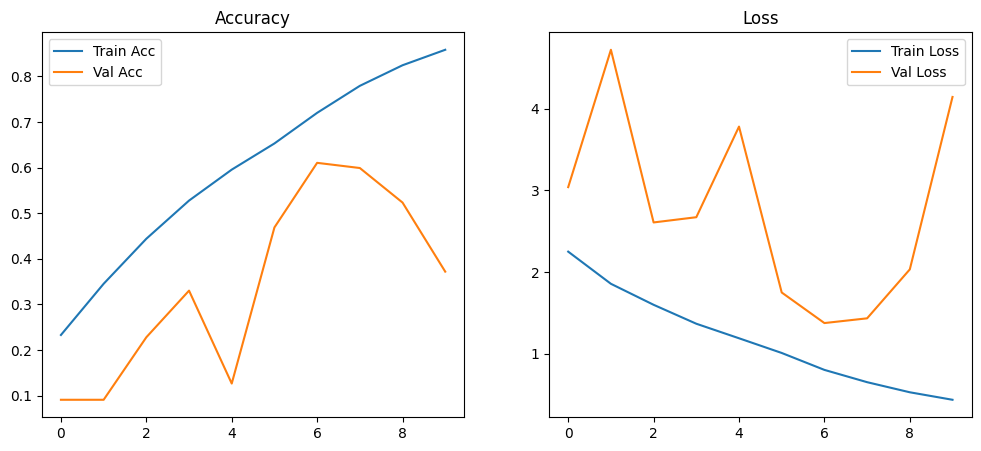

83/83 ━━━━━━━━━━━━━━━━━━━━ 53s 637ms/step - accuracy: 0.5894 - loss: 1.4617
Test Accuracy: 0.5894
83/83 ━━━━━━━━━━━━━━━━━━━━ 44s 472ms/step
                       precision    recall  f1-score      support
Alopecia Areata         0.772277  0.650000  0.705882   120.000000
Contact Dermatitis      0.577381  0.808333  0.673611   120.000000
Folliculitis            0.406897  0.491667  0.445283   120.000000
Head Lice               0.519337  0.783333  0.624585   120.000000
Lichen Planus           0.536585  0.550000  0.543210   120.000000
Male Pattern Baldness   0.855769  0.741667  0.794643   120.000000
Psoriasis               0.459459  0.283333  0.350515   120.000000
Seborrheic Dermatitis   0.702703  0.216667  0.331210   120.000000
Telogen Effluvium       0.372449  0.608333  0.462025   120.000000
Tinea Capitis           0.712121  0.391667  0.505376   120.000000
healthy hair            0.920000  0.958333  0.938776   120.000000
accuracy                0.589394  0.589394  0.589394     0.589394
ma

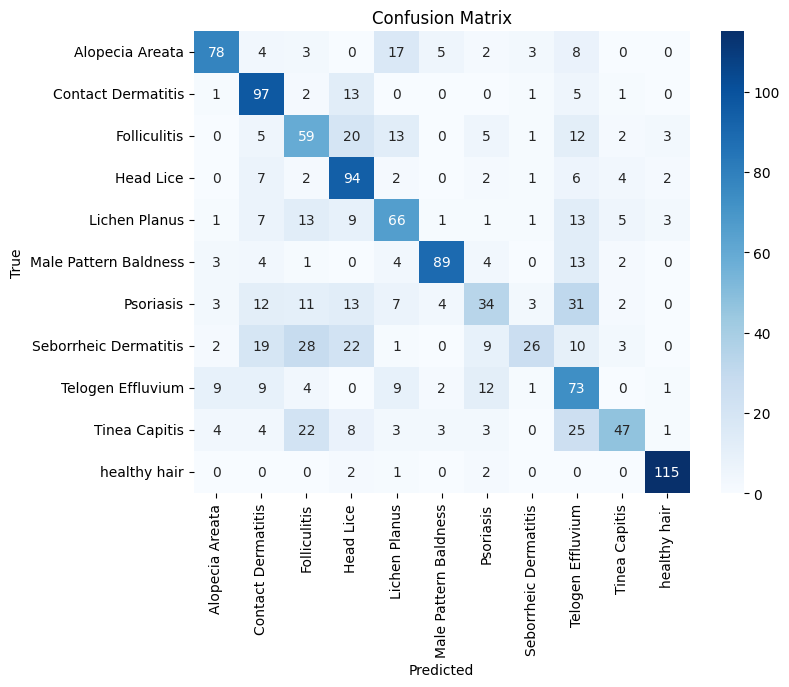

In [8]:
# ==============================
# 8️⃣ EVALUATION
# ==============================
# Accuracy/Loss Graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

# Test evaluation
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [9]:
# ==============================
# 9️⃣ SAVE MODEL
# ==============================
model.save("efficientnet_gray_model.h5")